In [1]:
# Instalação de dependências necessárias para a execução do notebook
%pip install -q numpy matplotlib scikit-learn torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Configuração de sementes fixas para garantir a reprodutibilidade dos experimentos
np.random.seed(42)
torch.manual_seed(42)

## 1. Contextualização histórica e motivação

Esta seção apresenta a origem do problema do sobreajuste e a necessidade fundamental de regularização no treinamento de modelos preditivos.

Modelos de Deep Learning modernos possuem arquiteturas suficientemente grandes e flexíveis para memorizar qualquer conjunto de dados, alcançando erro zero no treinamento. Historicamente, o objetivo do treinamento de um modelo não é decorar os dados vistos, mas sim aprender os padrões subjacentes para generalizar corretamente em dados ainda não vistos (dados de validação ou teste). Na década atual (2024-2025), com o advento de Grandes Modelos de Linguagem (LLMs) contendo bilhões de parâmetros, essa tendência à memorização torna-se um desafio crítico. O overfitting (sobreajuste) ocorre exatamente quando o modelo se adapta aos ruídos dos dados de treinamento, perdendo a capacidade de generalização. Para combater esse problema e simplificar a complexidade efetiva do modelo, pesquisadores introduziram diversas técnicas de regularização ao longo do tempo.

## 2. Intuição e visualização

Esta seção constrói a intuição visual de como modelos de diferentes complexidades se ajustam aos dados antes da introdução de fórmulas matemáticas.

O fenômeno de aprendizado pode ser visualizado através da regressão polinomial em um conjunto de dados ruidoso. O underfitting (subajuste) ocorre quando o modelo é demasiadamente simples, falhando em capturar a relação inerente dos dados. O overfitting ocorre quando um modelo demasiadamente complexo atravessa todos os pontos de treinamento exatos, incluindo o ruído. O optimal-fitting (ajuste ótimo) representa o cenário ideal, equilibrando a complexidade do modelo para capturar a curva geradora sem decorar os pontos exatos.

Observe que, graficamente, curvas de erro de validação divergem da curva de erro de treino quando o overfitting se inicia.

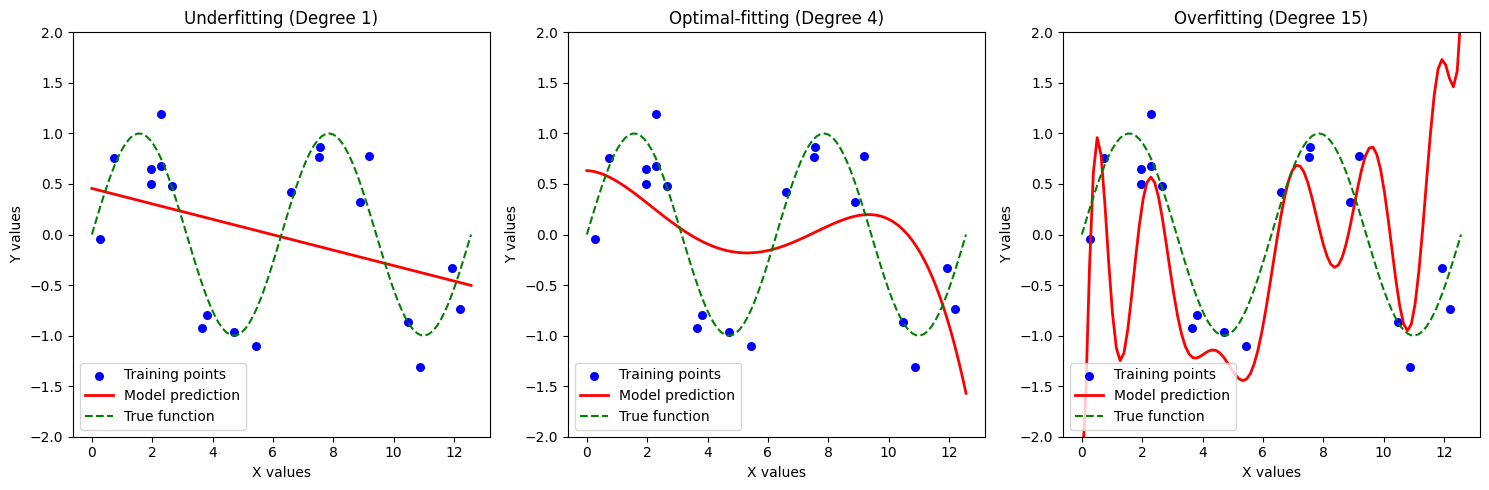

In [3]:
# Geração de dados sintéticos baseados em uma função seno com ruído
def generate_data(n_samples=30):
    X = np.sort(np.random.rand(n_samples) * 4 * np.pi)
    y = np.sin(X) + np.random.randn(n_samples) * 0.3
    return X[:, np.newaxis], y

X_train, y_train = generate_data(20)
X_test, y_test = generate_data(50)
X_plot = np.linspace(0, 4 * np.pi, 100)[:, np.newaxis]

# Criação de modelos com diferentes graus de complexidade
degrees = [1, 4, 15]
titles = ['Underfitting (Degree 1)', 'Optimal-fitting (Degree 4)', 'Overfitting (Degree 15)']

plt.figure(figsize=(15, 5))
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)

    # Criação de um pipeline com features polinomiais e regressão Ridge
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.0 if degree != 4 else 1e-3))
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)

    ax.scatter(X_train, y_train, color='blue', s=30, marker='o', label='Training points')
    ax.plot(X_plot, y_plot, color='red', linewidth=2, label='Model prediction')
    ax.plot(X_plot, np.sin(X_plot), color='green', linestyle='--', label='True function')

    ax.set_title(titles[i])
    ax.set_xlabel('X values')
    ax.set_ylabel('Y values')
    ax.set_ylim(-2, 2)
    ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

## 3. Teoria formal

Esta seção detalha as definições matemáticas e propriedades que governam o comportamento do overfitting, underfitting e as abordagens clássicas de regularização.

O estado do aprendizado de um modelo é frequentemente descrito pela relação (ou trade-off) entre viés e variância:

- Underfitting: Caracteriza-se por um alto viés e baixa variância. O modelo faz suposições muito fortes (simples) sobre os dados.
- Overfitting: Caracteriza-se por uma alta variância e baixo viés. O modelo muda drasticamente dependendo do conjunto de treinamento específico, memorizando padrões irrelevantes.

Para evitar o overfitting, introduz-se o conceito de regularização, cujo objetivo é restringir a complexidade do modelo, penalizando coeficientes muito altos.

**Regularização L1 (Lasso)**
A penalidade L1 é definida pela soma dos valores absolutos dos pesos. A função de custo $J(w)$ torna-se:
$$ J(w) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^p |w_j| $$
A L1 induz a esparsidade, forçando os coeficientes de features menos importantes exatamente a zero, operando como um mecanismo de seleção de variáveis.

**Regularização L2 (Ridge / Weight Decay)**
A penalidade L2 é definida pela soma do quadrado dos pesos. A função de custo é atualizada para:
$$ J(w) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^p w_j^2 $$
Na L2, o peso diminui substancialmente, mas raramente atinge zero. O quadrado do valor afeta agressivamente parâmetros muito grandes (pois $2^2 = 4$), enquanto diminui o impacto de variáveis pequenas (pois $0.1^2 = 0.01$).

**Dropout**
Dropout atua desativando aleatoriamente um subconjunto de neurônios a cada iteração do treinamento. Isso previne a coadaptação extrema de pesos e obriga o modelo a distribuir representações robustas por múltiplos caminhos da rede.

## 4. Algoritmos

Esta seção fornece a lógica estrutural, por meio de pseudocódigos, das técnicas de regularização discutidas antes de suas implementações.

**Algoritmo 1: Atualização de Gradiente Descendente com Weight Decay (L2)**
```text
INÍCIO
    Definir taxa de aprendizado (lr), peso atual (w), parâmetro de penalidade (lambda)
    Para cada iteração:
        1. Calcular o gradiente da função de perda em relação a w (grad)
        2. Adicionar a penalidade de decaimento: grad_reg = grad + 2 * lambda * w
        3. Atualizar o peso: w = w - lr * grad_reg
FIM
```
O decaimento dos pesos (L2) é calculado simplesmente somando a derivada de $w^2$ (que é proporcional a $w$) ao gradiente primário durante a atualização, forçando os pesos a diminuírem constantemente.

**Algoritmo 2: Forward Pass com Dropout**
```text
INÍCIO
    Definir probabilidade de desativação (p), matriz de ativação (A), modo (treino ou inferência)
    Se modo == treino:
        1. Gerar máscara aleatória M com a mesma forma de A usando distribuição uniforme [0, 1)
        2. Binarizar M: valores maiores que p tornam-se 1, o resto 0
        3. Aplicar máscara: A_drop = A * M
        4. Escalonar saídas: A_out = A_drop / (1 - p)
    Se modo == inferência:
        1. Manter A_out = A
FIM
```
Durante o treinamento, o Dropout zera as saídas com base em uma probabilidade $p$. Para garantir que a magnitude esperada do vetor na próxima camada permaneça inalterada, as ativações ativas são divididas por $(1 - p)$ durante o próprio treinamento. Na fase de inferência (avaliação), nenhum neurônio é desligado.

## 5. Implementação from scratch

Esta seção detalha a construção do mecanismo da Regressão Ridge (L2) puramente através de álgebra linear usando NumPy, validando sua exatidão com o ecossistema sklearn.

In [4]:
def ridge_regression_fit(X: np.ndarray, y: np.ndarray, alpha: float, penalize_bias: bool = False) -> np.ndarray:
    """
    Treina um modelo de Regressão Ridge (Regularização L2) utilizando a equação fechada.

    Args:
        X (np.ndarray): Matriz de features de formato (n_samples, n_features).
        y (np.ndarray): Vetor alvo de formato (n_samples,).
        alpha (float): Força da regularização (lambda).
        penalize_bias (bool): Se False, não penaliza a primeira coluna de X (bias).

    Returns:
        np.ndarray: Vetor de pesos estimados (n_features,).
    """
    n_features = X.shape[1]

    # Matematicamente: w = (X.T @ X + alpha * I)^(-1) @ X.T @ y
    I = np.eye(n_features)
    if not penalize_bias:
        I[0, 0] = 0.0

    X_T_X = np.dot(X.T, X)
    X_T_y = np.dot(X.T, y)

    inv_term = np.linalg.inv(X_T_X + alpha * I)
    weights = np.dot(inv_term, X_T_y)
    return weights

# ==========================================
# Validação contra o scikit-learn
# ==========================================
X_dummy = np.random.rand(100, 5)
X_dummy_bias = np.c_[np.ones((X_dummy.shape[0], 1)), X_dummy]
y_dummy = 3.5 * X_dummy[:, 0] - 1.2 * X_dummy[:, 2] + np.random.randn(100) * 0.1

alpha_param = 1.0

# 1. Nossa implementação From Scratch
weights_scratch = ridge_regression_fit(X_dummy_bias, y_dummy, alpha=alpha_param, penalize_bias=False)

# 2. Implementação do Sklearn
sk_ridge = Ridge(alpha=alpha_param, fit_intercept=True)
sk_ridge.fit(X_dummy, y_dummy)
weights_sklearn = np.insert(sk_ridge.coef_, 0, sk_ridge.intercept_)

np.testing.assert_almost_equal(weights_scratch, weights_sklearn, decimal=5)
print('Sucesso: A implementação from scratch produz pesos idênticos ao Scikit-Learn!')

Sucesso: A implementação from scratch produz pesos idênticos ao Scikit-Learn!


## 6. Implementação em PyTorch

Esta seção transita a teoria para o uso em redes neurais de fato, explorando o Dropout em frameworks de alto nível e explicitando o papel dos modos de execução da API.

Observe que invocar model.train() instrui o PyTorch a ligar os comportamentos probabilísticos de camadas como Dropout. Por outro lado, model.eval() congela as probabilidades, garantindo avaliações determinísticas em dados de inferência. Nunca testar um modelo em estado train() é uma regra primária, visto que o erro de saída e as predições seriam desestabilizadas e estocásticas.

In [5]:
class RegularizedMLP(torch.nn.Module):
    """
    Multi-Layer Perceptron simples que aplica a regularização técnica de Dropout.
    """
    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float = 0.5):
        super(RegularizedMLP, self).__init__()
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=dropout_prob)
        self.layer2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.layer1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.layer2(out)
        return out

# Inicialização da rede
model = RegularizedMLP(input_dim=10, hidden_dim=20, dropout_prob=0.5)

# Demonstração
sample_input = torch.randn(5, 10)

# Modo de Treino
model.train()
out_train_1 = model(sample_input)
out_train_2 = model(sample_input)
assert not torch.allclose(out_train_1, out_train_2), 'No modo train(), saídas devem divergir por causa do Dropout estocástico.'

# Modo de Avaliação
model.eval()
out_eval_1 = model(sample_input)
out_eval_2 = model(sample_input)
assert torch.allclose(out_eval_1, out_eval_2), 'No modo eval(), saídas devem ser determinísticas.'

print('A asserção confirmou o comportamento de model.train() e model.eval() perfeitamente!')

A asserção confirmou o comportamento de model.train() e model.eval() perfeitamente!


## 7. Experimentos e análise

Esta seção estrutura um experimento laboratorial robusto, medindo como o ajuste de hiperparâmetros (penalidade L2) atua diretamente sobre dados ruidosos.

A prática rigorosa de ciência de dados exige compreender o problema e evitar o data leakage (vazamento de dados), situação na qual o modelo recebe informações indesejadas (como dados temporais futuros) na fase de treinamento. Para mensurar o efeito da regularização livre de viés de teste, monitora-se a separação do erro de treinamento e de erro de validação. A seguir, dois ciclos de treino são apresentados: um sem decaimento de pesos (L2 = 0) e outro com uma pesada regularização.

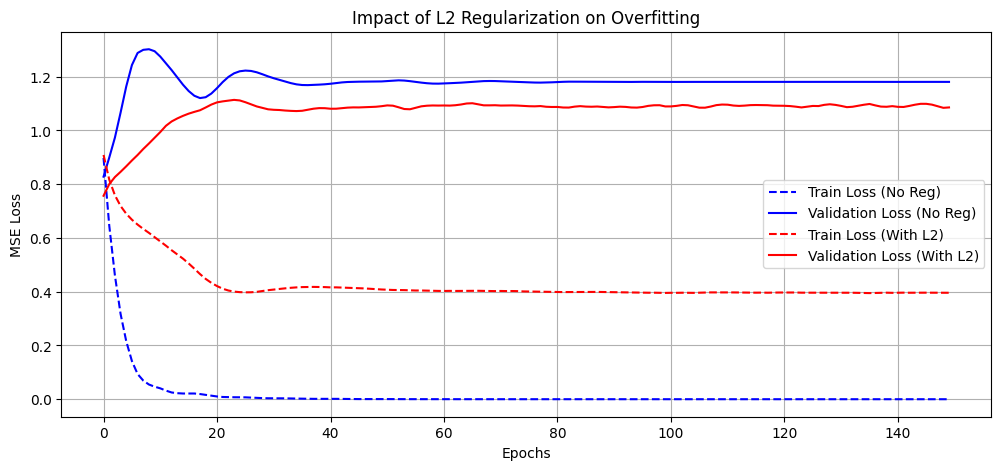

In [6]:
# Geração de dataset artificialmente difícil e ruidoso para forçar overfitting
X_exp = torch.randn(100, 50)
y_exp = torch.randn(100, 1)

# Split seguro
train_idx = int(0.8 * len(X_exp))
X_tr, y_tr = X_exp[:train_idx], y_exp[:train_idx]
X_val, y_val = X_exp[train_idx:], y_exp[train_idx:]

def train_experiment(weight_decay_val: float):
    exp_model = RegularizedMLP(input_dim=50, hidden_dim=100, dropout_prob=0.0)
    optimizer = torch.optim.Adam(exp_model.parameters(), lr=0.01, weight_decay=weight_decay_val)
    criterion = torch.nn.MSELoss()

    history_train, history_val = [], []

    for epoch in range(150):
        exp_model.train()
        optimizer.zero_grad()
        loss_train = criterion(exp_model(X_tr), y_tr)
        loss_train.backward()
        optimizer.step()

        exp_model.eval()
        with torch.no_grad():
            loss_val = criterion(exp_model(X_val), y_val)

        history_train.append(loss_train.item())
        history_val.append(loss_val.item())

    return history_train, history_val

# Rodando os experimentos
train_no_reg, val_no_reg = train_experiment(weight_decay_val=0.0)
train_reg, val_reg = train_experiment(weight_decay_val=0.5)

# Visualização analítica
plt.figure(figsize=(12, 5))
plt.plot(train_no_reg, label='Train Loss (No Reg)', color='blue', linestyle='--')
plt.plot(val_no_reg, label='Validation Loss (No Reg)', color='blue')

plt.plot(train_reg, label='Train Loss (With L2)', color='red', linestyle='--')
plt.plot(val_reg, label='Validation Loss (With L2)', color='red')

plt.title('Impact of L2 Regularization on Overfitting')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

No gráfico gerado, nota-se que na ausência de regularização (linha azul tracejada), o erro de treinamento cai sistematicamente, sugerindo aprendizado, enquanto o erro de validação cresce bruscamente, confirmando o overfitting. A curva vermelha (com penalidade de pesos L2/weight decay alta) impede que a rede decore os ruídos. É evidente que projetar experimentos corretamente desenhados é a melhor técnica global para evitar overfitting surpresa na produção.

## 8. Conexões com ML moderno

Esta seção contextualiza como as fórmulas e lógicas apresentadas anteriormente embasam modelos e otimizadores complexos amplamente estudados em Inteligência Artificial no ano de 2025.

Em frameworks de linguagem avançados baseados em Transformers, bem como em algoritmos de difusão de imagens, uma rede suficientemente parametrizada com bilhões de pesos detém a matemática e a escala necessárias para memorizar todo o conjunto de treinamento, resultando em desempenho medíocre em prompts reais. O Weight Decay (regularização L2) desempenha um papel crítico na mitigação deste problema e foi até mesmo remodelado e desacoplado matematicamente da fórmula do momento nos gradientes clássicos para dar origem ao algoritmo padrão ouro atual, o otimizador AdamW.

- Loshchilov, I., & Hutter, F. (2017). Decoupled Weight Decay Regularization (AdamW). Este paper corrige uma falha de formulação da L2 presente dentro da iteração clássica do otimizador Adam, desacoplando o decaimento e provando ser muito mais efetivo na preservação de generalização.

Mesmo com toda a evolução teórica, avaliar diligentemente as fatias isoladas de teste separadas dos recortes de treinamento para evitar o data leakage ainda constitui o pilar que garante as entregas confiáveis do aprendizado de máquina em 2025.

## 9. Exercícios

Esta seção estimula a fixação prática de toda a fundamentação teórica através de casos aplicados e desafios projetivos abertos.

**Exercício Resolvido 1:** Por que as GPUs rodam redes profundas com alta eficiência baseando-se que a rede tenha normalização e dados esparsos regularizados?
**Solução:** Além da natureza intrinsecamente paralela na multiplicação matricial suportada pelas GPUs, o ecossistema de baixo nível dessas placas é desenhado prevendo dados numéricos normalizados em uma média zero e variância aproximada em 1, que evita estouros ou instabilidades nas floating points. Modelos que não aplicam boas práticas limitam consideravelmente sua velocidade otimizada por essas unidades. Adicionalmente, quando aplica-se um L1 em vez de L2, forçando ativações de pesos a zero e reduzindo os caminhos, economiza-se indiretamente no uso de tensores durante iterações parciais.

**Exercício Resolvido 2:** No ecossistema do PyTorch, o que ocorre quando se invoca .eval() em um modelo sem Dropout e sem camadas de BatchNorm (apenas Linear e ReLU)?
**Solução:** Nestas arquiteturas isoladas, .eval() não provoca alteração fundamental no comportamento de inferência. A invocação do modo de avaliação é concebida expressamente para congelar camadas que dependem de variáveis estocásticas aleatórias como o Dropout e nas camadas de Batch Normalization (onde deixa de recalcular os parâmetros estatísticos do mini-batch momentâneo para usar a estatística móvel retida na base global de treinamento).

**Exercício Resolvido 3:** Dado um problema de predição temporal (por exemplo: prever a variação acionária no mercado financeiro diário), como a quebra aleatória entre treino e teste pode provocar data leakage?
**Solução:** A aleatoriedade insere dados de contextos espaciais futuros ou temporalmente posteriores no treinamento. O modelo terá lido as reações do mercado em 2020 para deduzir e avaliar uma linha base da previsão de uma queda em 2018. O modelo estaria trapaceando ao aprender o porvir cronológico indesejado, não prevendo forward-time, apresentando precisão fantasma que quebra inevitavelmente no mundo real não treinado.

**Desafio Aberto 1:** Manipulação de L1 from Scratch em PyTorch.
**Dica:** Escreva um laço de treinamento manual em PyTorch (for param in model.parameters()). Utilize a propriedade param.data e submeta os pesos a uma penalidade L1 na função de custo (lembre-se do torch.abs(param)). Avalie como a sparsity (parâmetros rigorosamente nulos) se propaga perante valores agressivos de $\lambda$.

**Desafio Aberto 2:** Simulação de Leaked Validation Data.
**Dica:** Desenvolva um experimento carregando um dataset sequencial temporal. No cenário A, faça um train_test_split(..., shuffle=True) puro. No cenário B, fatie estritamente com base no índice de datas (data[:80], data[80:]). Utilize Random Forest ou MLP. Monitore e redija os laudos de discrepância na curva ROC ou MSE gerada no cenário A (falsa segurança).